## Face landmark 함수 및 필요 라이브러리 임포트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 필요 라이브러리 임포트
!pip install cmake

!pip install dlib
!pip install imutils
!pip install opencv-python

from google.colab.patches import cv2_imshow # Google Colab에서 이미지 출력을 위한 함수

from imutils import face_utils  # dlib에서 사용하는 페이셜 유틸리티 함수
import numpy as np # 다차원 배열 데이터 처리를 위한 라이브러리
import imutils # 이미지 처리를 위한 함수를 제공하는 라이브러리
import dlib  # 얼굴 인식과 랜드마크 검출을 위한 라이브러리
import cv2  # 영상 처리를 위한 라이브러리입니다.

# 입력 이미지의 얼굴 전체를 검출하여 랜드마크를 그리는 함수
def show_raw_detection(image, detector, predictor):
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # 이미지를 회색으로 변경

  rects = detector(gray, 1) # 회색으로 바꾼 이미지를 검출기에 넣음.

  for(i, rect) in enumerate(rects):
    shape = predictor(gray, rect)
    shape = face_utils.shape_to_np(shape) # 검출한 얼굴 영역에서 랜드마크 검출.

    (x,y,w,h) = face_utils.rect_to_bb(rect)
    cv2.rectangle(image, (x,y), (x+w, y+h), (0,255,0),2) # 검출된 얼굴 영역을 사각형으로 표시.

    cv2.putText(image, "Face #{}".format(i+1), (x -10, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2) # 각 얼굴 영역에 번호를 부여해서 출력
    for(x,y) in shape:
      cv2.circle(image, (x,y), 1, (0, 0, 255), -1) # 검출된 랜드마크 출력

  cv2_imshow(image) # 사진 출력
  cv2.waitKey(0)


# 입력 이미지의 부위 별 이미지를 검출하여 그리는 함수
def draw_individual_detections(image, detector, predictor):
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # 이미지를 회색으로 변경

  rects = detector(gray,1) # 회색으로 바꾼 이미지를 검출기에 넣음.

  for(i, rect) in enumerate(rects):

    shape = predictor(gray, rect)
    shape = face_utils.shape_to_np(shape)  # 얼굴 랜드마크 좌표값을 numpy 배열로 변환


    for(name, (i,j)) in face_utils.FACIAL_LANDMARKS_IDXS.items():
      clone = image.copy()  # 이미지를 복사
      cv2.putText(clone, name, (10,30),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255),2) # 랜드마크 이름을 출력

      for(x,y) in shape[i:j]: # 현재 랜드마크 영역내의 모든 좌표에 대해 반복
        cv2.circle(clone, (x,y), 1, (0,0,255), -1)  # 검출된 랜드마크를 출력

      (x,y,w,h) = cv2.boundingRect(np.array([shape[i:j]]))# 현재 랜드마크 영역의 경계 사각형을 구함
      roi = image[y : y+h, x : x+w] # 랜드마크를 검출한 얼굴 영역을 자름
      roi = imutils.resize(roi, width = 250, # 잘라낸 영역의 크기를 조정
                           inter = cv2.INTER_CUBIC)

      cv2_imshow(roi) # 잘라낸 영역을 출력
      cv2_imshow(clone) # 랜드마크를 표시한 이미지를 출력
      cv2.waitKey(0)  # 아무 키나 누르면 종료
    output = face_utils.visualize_facial_landmarks(image, shape) # 랜드마크를 시각화한 이미지를 출력
    cv2_imshow(output)
    cv2.waitKey(0)

## Face landmark를 이용하여 사진 특징 추출

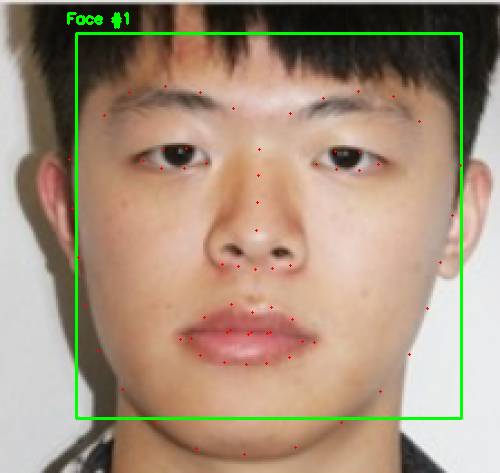

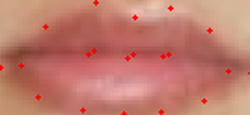

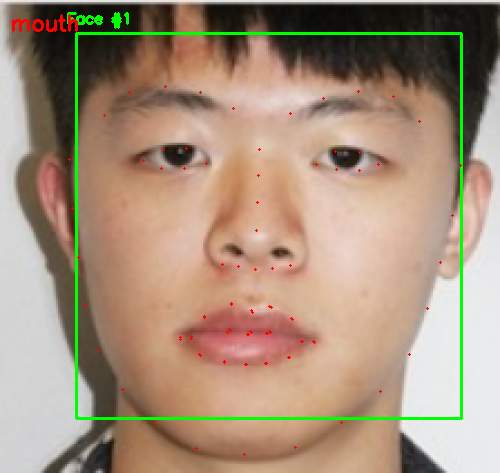

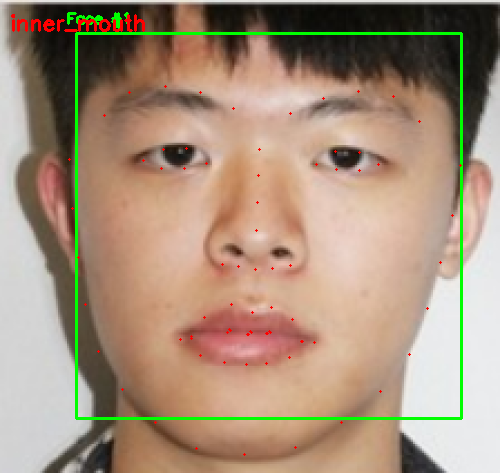

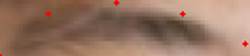

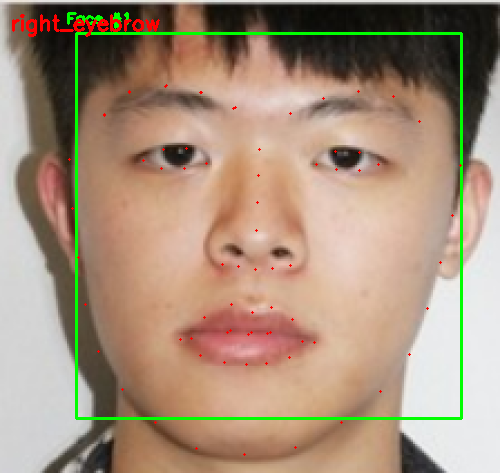

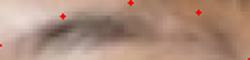

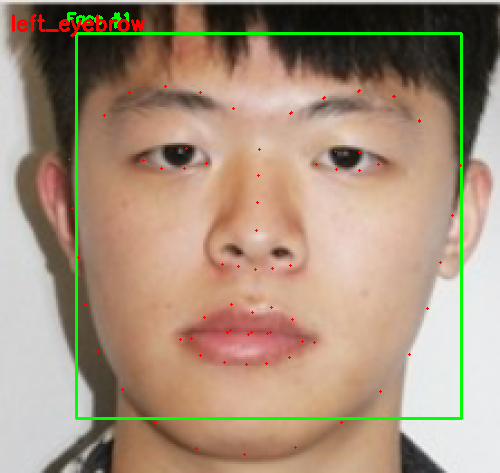

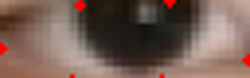

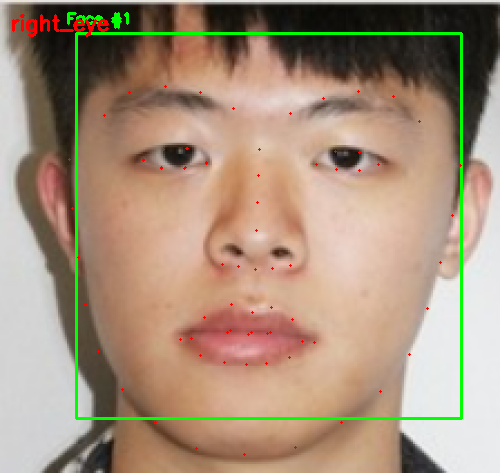

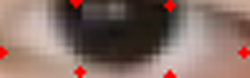

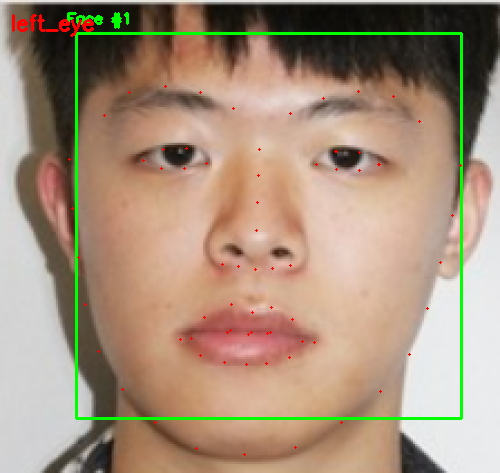

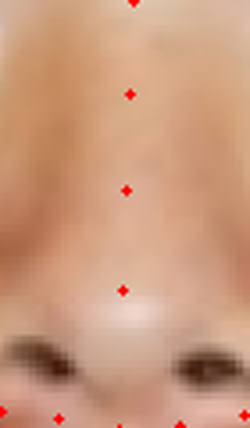

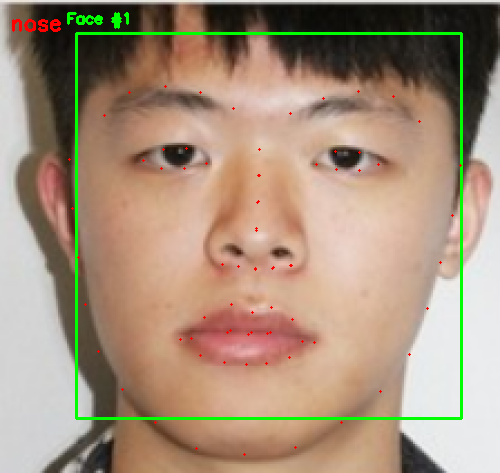

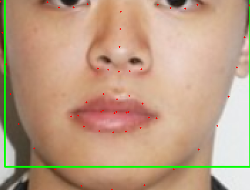

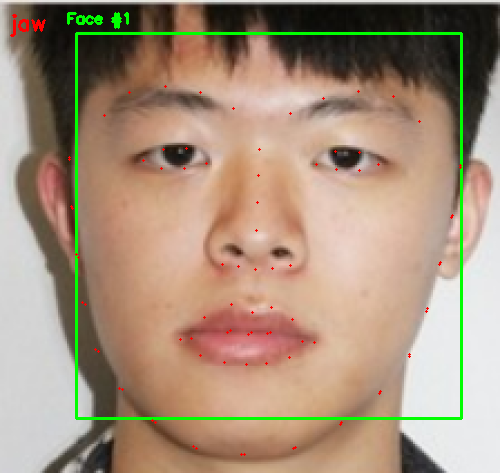

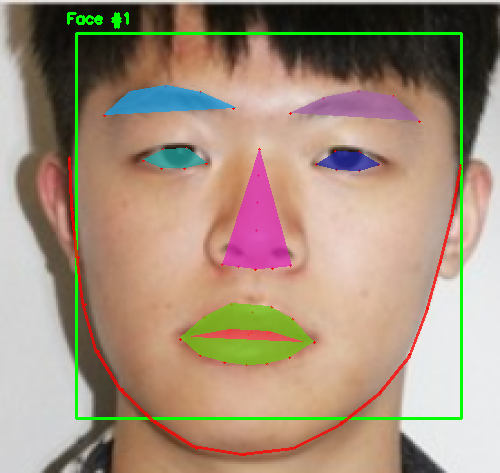

In [ ]:

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor('/content/drive/MyDrive/Colab Notebooks/프로젝트_stroke/shape_predictor_68_face_landmarks.dat')
image = cv2.imread('/content/스크린샷 2023-08-22 103219.png')

image = imutils.resize(image, width = 500)

show_raw_detection(image, detector, predictor)
draw_individual_detections(image, detector, predictor)

## 입술 좌표 특성치 따기

In [ ]:
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor('/content/drive/MyDrive/Colab Notebooks/프로젝트_stroke/shape_predictor_68_face_landmarks.dat')
image = cv2.imread('/content/스크린샷 2023-08-22 103219.png')
image = imutils.resize(image, width = 500)

# 이미지 파일을 불러서 얼굴 영역을 검출
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
rects = detector(gray, 1)

# 검출된 얼굴 영역 중에서 최초의 하나만 사용
# 만약 여러 개의 얼굴 영역이 검출된다면 다른 방법
for (i, rect) in enumerate(rects):
    shape = predictor(gray, rect)
    shape = face_utils.shape_to_np(shape)

    # "Mouth" 라는 이름을 가진 랜드마크 영역에 대한 좌표값
    # 48번 랜드마크부터 68번 랜드마크까지가 "Mouth" 영역
    mouth_coords = shape[48:68]

# mouth_coords에는 입술 랜드마크 좌표값
# 만약 이 좌표값이 2차원 배열 형태로 필요하다면 아래와 같이 처리

mouth_coords = np.array(mouth_coords)

'''
x_mean = np.mean(mouth_coords, axis = (0, 1))
x_std = np.std(mouth_coords, axis = (0, 1))

# 스케일링 (Standardization)
mouth_coords = (mouth_coords - x_mean) / x_std
'''


'\nx_mean = np.mean(mouth_coords, axis = (0, 1))\nx_std = np.std(mouth_coords, axis = (0, 1))\n\n# 스케일링 (Standardization)\nmouth_coords = (mouth_coords - x_mean) / x_std\n'

In [ ]:
import pandas as pd

# 얼굴 검출을 위한 dlib의 face detector 객체 생성
detector = dlib.get_frontal_face_detector()
# 68개 얼굴 랜드마크 예측 모델 로드
predictor = dlib.shape_predictor('/content/drive/MyDrive/Colab Notebooks/프로젝트_stroke/shape_predictor_68_face_landmarks.dat')

# 입술의 랜드마크 좌표 추출을 위한 함수 정의
def get_lip_landmarks(image):
    # 이미지를 RGB로 변환
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # 이미지의 gray 변환
    #gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    # 얼굴 검출 수행
    rects = detector(gray, 1)
    # 입술 랜드마크 좌표 추출
    if len(rects)>0:
        shape = predictor(gray, rects[0])
        shape = face_utils.shape_to_np(shape)
        lip_points = [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67]
        lip_landmarks = np.array([shape[idx] for idx in lip_points])
        return lip_landmarks.flatten()
    else:
        return None
######
# 데이터프레임 생성을 위한 리스트 객체 생성
features = []
results = []

# 이미지 데이터셋의 경로(여기서는 "/content/images" 폴더 내에 있는 이미지들을 사용)
import os
path_to_images = "/content/drive/MyDrive/Colab Notebooks/프로젝트_stroke/images2"

for file_name in os.listdir(path_to_images):
    # 이미지를 읽어온 뒤 facelandmark를 추출
    image = cv2.imread(os.path.join(path_to_images, file_name))
    landmarks = get_lip_landmarks(image)
    if landmarks is not None:
        # facelandmark를 features 리스트 객체에 추가
        features.append(landmarks)
        # 결과값(1)을 results 리스트 객체에 추가 -> 뇌졸중
        results.append(1)

path_to_images = "/content/drive/MyDrive/Colab Notebooks/프로젝트_stroke/images3"
for file_name in os.listdir(path_to_images):
    # 이미지를 읽어온 뒤 facelandmark를 추출
    image = cv2.imread(os.path.join(path_to_images, file_name))
    landmarks = get_lip_landmarks(image)
    if landmarks is not None:
        # facelandmark를 features 리스트 객체에 추가
        features.append(landmarks)
        # 결과값(1)을 results 리스트 객체에 추가 ->정상
        results.append(0)

# features와 results를 이용하여 데이터프레임 생성
df = pd.DataFrame(features)
df['result'] = results
df.columns = ['feature_' + str(i) for i in range(len(df.columns)-1)] + ['result']

In [ ]:
df

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,result
0,180,339,204,317,231,304,252,312,271,307,...,332,302,341,267,333,248,334,227,332,1
1,180,339,204,317,231,304,252,312,271,307,...,332,302,341,267,333,248,334,227,332,1
2,180,339,204,317,231,304,252,312,271,307,...,332,302,341,267,333,248,334,227,332,1
3,180,339,204,317,231,304,252,312,271,307,...,332,302,341,267,333,248,334,227,332,1
4,180,339,204,317,231,304,252,312,271,307,...,332,302,341,267,333,248,334,227,332,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,180,339,204,317,231,304,252,312,271,307,...,332,302,341,267,333,248,334,227,332,0
549,180,339,204,317,231,304,252,312,271,307,...,332,302,341,267,333,248,334,227,332,0
550,180,339,204,317,231,304,252,312,271,307,...,332,302,341,267,333,248,334,227,332,0
551,180,339,204,317,231,304,252,312,271,307,...,332,302,341,267,333,248,334,227,332,0


In [ ]:
X = df.drop('result', axis=1)
y = df['result']

X = np.array(X)
y = np.array(y)

'''
# 평균과 표준편차는 채널별로 구해줍니다.
x_mean = np.mean(X, axis = (0, 1))
x_std = np.std(X, axis = (0, 1))

# 스케일링 (Standardization)
X = (X - x_mean) / x_std
'''


'\n# 평균과 표준편차는 채널별로 구해줍니다.\nx_mean = np.mean(X, axis = (0, 1))\nx_std = np.std(X, axis = (0, 1))\n\n# 스케일링 (Standardization)\nX = (X - x_mean) / x_std\n'

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (442, 40)
y_train shape: (442,)
X_test shape: (111, 40)
y_test shape: (111,)


In [ ]:
import numpy as np
from keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential

# 데이터 생성
X_train = np.random.rand(321, 40)
y_train = np.random.randint(2, size=321)
y_train = to_categorical(y_train)

# 모델 구성
model = Sequential()
model.add(Conv2D(64, (3, 3), input_shape=(1, 40, 1), activation='relu')) # Conv1D 를 Conv2D로 변경 및 필터 크기 수정
model.add(MaxPooling2D(pool_size=(1, 2))) # MaxPooling1D 를 MaxPooling2D로 변경 및 풀링 크기 수정
model.add(Conv2D(128, (3, 3), activation='relu')) # Conv1D 를 Conv2D로 변경 및 필터 크기 수정
model.add(MaxPooling2D(pool_size=(1, 2))) # MaxPooling1D 를 MaxPooling2D로 변경 및 풀링 크기 수정
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(2, activation='softmax'))

# 모델 설정
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# X_train 데이터 Shape 변환
X_train = X_train.reshape((X_train.shape[0], 1,  X_train.shape[1], 1)) # 2차원 형태로 변경

# 모델 학습
model.fit(X_train, y_train, epochs=25, batch_size=32)

ValueError: ignored

In [ ]:
X_train.shape

(321, 40, 1)

In [ ]:
X_test.shape

(111, 40)

In [ ]:
# 입력 데이터 reshape
mouth_coords = mouth_coords.reshape((1, 40, 1))

# 모델 예측
prediction = model.predict(mouth_coords, batch_size=None)

if prediction[0][0] > prediction[0][1]:
    print("예측 결과: 이 이미지는 클래스 0입니다.")
else:
    print("예측 결과: 이 이미지는 클래스 1입니다.")

1/1 [==============================] - 0s 391ms/step
예측 결과: 이 이미지는 클래스 0입니다.


In [ ]:
num_classes = 2 # 분류하려는 클래스의 개수

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

y_pred = (model.predict(X_test) > 0.5).astype("int32")   # 출력값을 0 또는 1의 형태로 변환

# y_test_binary 배열을 이진 벡터로 변환
y_test_binary = np.zeros((len(y_pred), num_classes))
for i in range(y_pred.shape[0]):
    y_test_binary[i, y_test[i]] = 1

# 분류 정확도 계산
accuracy = np.mean(y_pred == y_test_binary)
print("Accuracy:", accuracy)

4/4 [==============================] - 0s 8ms/step
Accuracy: 0.18018018018018017


In [ ]:
y_test

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [ ]:
y_pred


array([[1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1,